## Gibbs Sampling for Normal Model with Unknown Mean and Variance


Daily stock market returns follow a normal distribution with an unknown mean $\mu$ and variance $\sigma^2$. We observe daily returns from the stock market over n=100 days, and we want to estimtae the posterior distributions for $\mu$ and $\sigma$. We start by loading the data.



In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import invgamma

# Step 1: load data
data = np.loadtxt("data/stock_market_daily.csv")

### Priors

Like in every Bayesian inference problem we start by setting priors for the parameters we want to estimate:

$\mu \sim \mathcal{N}(\mu_0, \tau^2), \qquad \sigma^2 \sim \text{Inv-Gamma}(a_0, b_0)
$

Here we have assumed that the prior for the mean $\mu$ follows a normal distribution, and the prior for the variance follows an inverse Gamma. These priors are conjugate to the likelihood, and thus, it will allow us to have a closed form for the Gibbs updates.

---

### Full Conditionals for Gibbs Sampling:

For Gibbs sampling we sample each parameter using its conditional posterior holding the other parameters fixed. The benefit we have here is that each of the conditionals is conjugate to its likelihoods so we can use the conjugacy to get a closed form for the updates.
[This](https://en.wikipedia.org/wiki/Conjugate_prior#Table_of_conjugate_distributions) table has a coprehensive list of posterior updates.
We start by sampling the posterior $\mu$ assuming $\sigma^2$ is fixed:

---

#### 1. Sampling $ \mu \mid \sigma^2, \mathbf{x} $:

$\mu \mid \sigma^2, \mathbf{x} \sim \mathcal{N}(\mu_n, \tau_n^2)
$

The conditional posterior for $\mu$ follows a normal with parameters:

$\mu_n = \frac{\mu_0 / \tau^2 + n \bar{x} / \sigma^2}{1 / \tau^2 + n / \sigma^2}, \quad
\tau_n^2 = \left( \frac{1}{\tau^2} + \frac{n}{\sigma^2} \right)^{-1}
$

where the sample mean is:

$
\bar{x} = \frac{1}{n} \sum_{i=1}^n x_i
$

---

We then continue sampling with the second parameter, i.e., $\sigma^2$, assuming $\mu$ is fixed.

---

#### 2. Sampling $ \sigma^2 \mid \mu, \mathbf{x} $:

$
\sigma^2 \mid \mu, \mathbf{x} \sim \text{Inv-Gamma}(a_n, b_n)
$

The conditional posterior for $\sigma^2$ follows an inverse Gamma distribuion with parameters:

$
a_n = a_0 + \frac{n}{2}, \quad
b_n = b_0 + \frac{1}{2} \sum_{i=1}^n (x_i - \mu)^2
$

---

### Gibbs Sampling Algorithm:

Starting with initial values $ \mu^{(0)}, \sigma^{2\,(0)} $, repeat:

$
\mu^{(t+1)} \mid \sigma^{2\,(t)}\sim \mathcal{N}(\mu_n, \tau_n^2)
$

$
\sigma^{2\,(t+1)} \mid \mu^{(t+1)} \sim \text{Inv-Gamma}(a_n, b_n)
$

In [ ]:
# Step 2: Gibbs sampler
def gibbs_normal_unknown_mean_var(data, mu0, tau2, a0, b0, n_iter=5000):
    n = len(data)
    x_bar = np.mean(data)

    # Initialize values
    mu = x_bar
    sigma2 = np.var(data)
    samples = []

    for _ in range(n_iter):
        # --- Update mu | sigma2, data ---
        mu_n = (mu0 / tau2 + n * x_bar / sigma2) / (1 / tau2 + n / sigma2)
        tau2_n = 1 / (1 / tau2 + n / sigma2)
        mu = np.random.normal(mu_n, np.sqrt(tau2_n))

        # --- Update sigma^2 | mu, data ---
        a_n = a0 + n / 2
        b_n = b0 + 0.5 * np.sum((data - mu) ** 2)
        sigma2 = invgamma.rvs(a_n, scale=b_n)

        samples.append((mu, sigma2))

    return np.array(samples)


The above function initializes the sampling process setting $\mu^{(0)}$ to the sampling mean of the data and setting $\sigma^{2\,(0)}$ to the sample variance of the data. The `for-loop` goes over the conjugate conditional  formulas we saw above, updating first $\mu$ and then $\sigma^2$.

In the following we call the Gibbs sampling function with the parameters for our priors.  

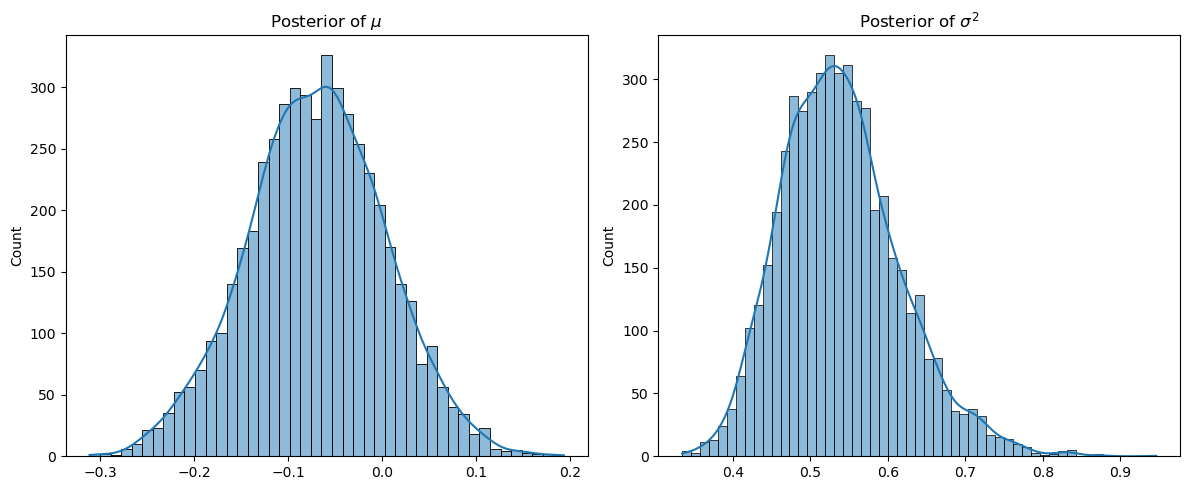

In [ ]:
# Step 3: Run the sampler
samples = gibbs_normal_unknown_mean_var(data, mu0=0, tau2=10, a0=2, b0=2, n_iter=5000)

# Step 4: Plot the posterior distributions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(samples[:, 0], kde=True)
plt.title(r"Posterior of $\mu$")

plt.subplot(1, 2, 2)
sns.histplot(samples[:, 1], kde=True)
plt.title(r"Posterior of $\sigma^2$")

plt.tight_layout()
plt.show()


As we can see the posterior of $\mu$ has shifted from the prior value of 0, since the data we have observed support a slightly negative daily return.

# Posterior Predictive

After obtaining the samples for the posteriors of $\mu$ and $\sigma^2$, we can generate the posterior predictive distribution. This is how one makes Bayesian predictions.

The posterior predictive distribution for a new observation $x^*$ is:

$
p(x^* \mid \mathbf{x}) = \int p(x^* \mid \mu, \sigma^2) \cdot p(\mu, \sigma^2 \mid \mathbf{x}) \, d\mu \, d\sigma^2
$

We cannot evaluate this integral analytically in general, so we use samples from the posterior to approximate it.
### Sampling-Based Posterior Predictive

Let $ \{(\mu^{(t)}, \sigma^{2\,(t)})\}_{t=1}^T $ be samples from the posterior distribution $ p(\mu, \sigma^2 \mid \mathbf{x}) $ you sampled through Gibbs sampling.

Then, we can approximate the posterior predictive by:

$
x^{*(t)} \sim \mathcal{N}(\mu^{(t)}, \sigma^{2\,(t)}), \quad t = 1, \dots, T
$

The collection $ \{x^{*(t)}\}_{t=1}^T $ represents samples from the **posterior predictive distribution**.


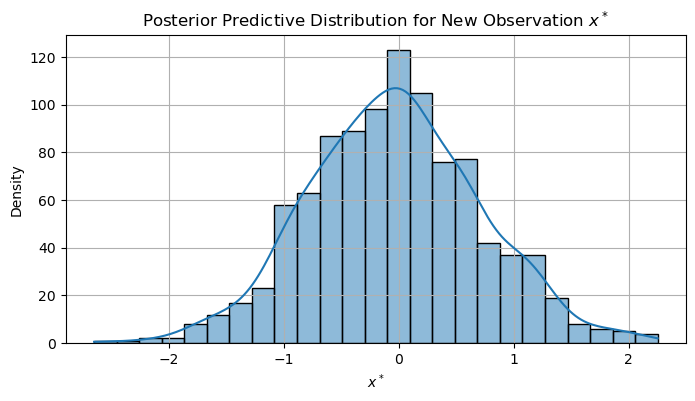

In [9]:
# Draw posterior predictive samples
n_predict = 1000
posterior_predictive = np.random.normal(
    loc=samples[-n_predict:, 0],                # sampled mu
    scale=np.sqrt(samples[-n_predict:, 1])      # sampled sigma
)

# Plot posterior predictive distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.histplot(posterior_predictive, kde=True)
plt.title("Posterior Predictive Distribution for New Observation $x^*$")
plt.xlabel("$x^*$")
plt.ylabel("Density")
plt.grid(True)
plt.show()


The posterior predictive incorporates the uncertainty in both parameters and data, and can be used to compute things like predictive intervals, predictive mean, predictive mode etc.

# Burn-In

Typically we should use a burn-in period when running a Gibbs sampler (or any MCMC algorithm).
Burn-in discards the initial samples, where the chain might not have yet reached the steady-state.
A typical approach is to burn-in the first 10-15\% of the samples:

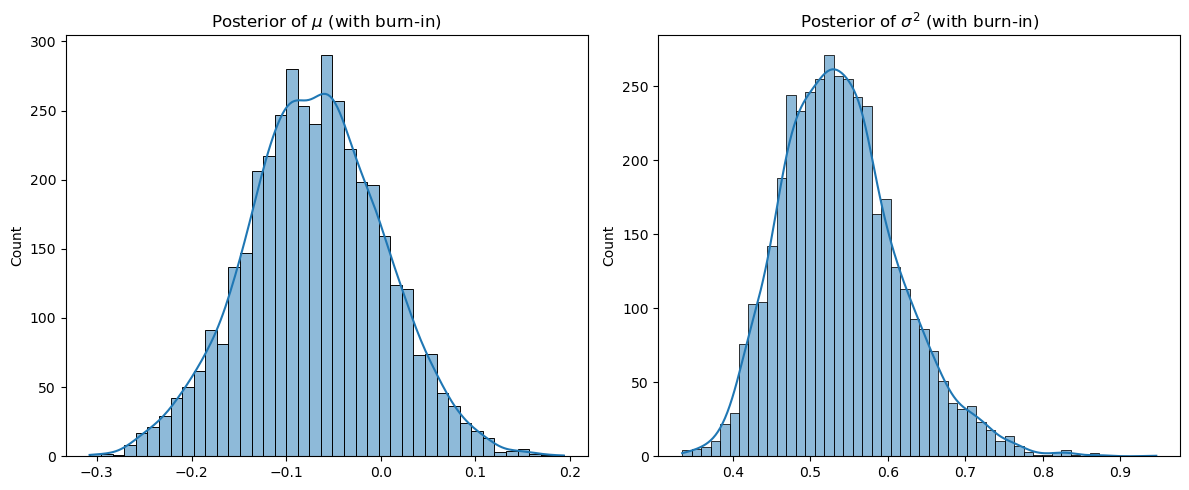

In [10]:
# we burn-in the first 1000 samples
samples = samples[1000:]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(samples[:, 0], kde=True)
plt.title(r"Posterior of $\mu$ (with burn-in)")

plt.subplot(1, 2, 2)
sns.histplot(samples[:, 1], kde=True)
plt.title(r"Posterior of $\sigma^2$ (with burn-in)")

plt.tight_layout()
plt.show()